In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/unique_tech_classroom_air_quality.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
df.shape

(500, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   school_period            500 non-null    object 
 2   student_count_estimated  500 non-null    int64  
 3   co2_ppm                  500 non-null    float64
 4   pm25_ugm3                500 non-null    float64
 5   temperature_c            500 non-null    float64
 6   humidity_pct             500 non-null    float64
 7   robot_x_pos              500 non-null    float64
 8   robot_y_pos              500 non-null    float64
 9   ventilation_decision     500 non-null    object 
 10  air_quality_label        500 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 43.1+ KB


In [6]:
df.describe()

,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,11.184000,619.266400,8.439960,20.48980,44.594400,2.005800,1.990000
std,9.446301,155.967082,2.718404,0.19191,3.057506,1.415639,1.420781
min,0.000000,432.200000,4.400000,20.20000,41.300000,0.000000,0.000000
25%,3.000000,493.825000,6.170000,20.40000,41.800000,0.600000,0.600000
50%,7.000000,529.200000,7.080000,20.50000,42.800000,2.050000,2.000000
75%,22.000000,801.425000,11.512500,20.50000,47.800000,3.400000,3.400000
max,27.000000,893.000000,14.500000,21.00000,49.700000,4.000000,4.000000


In [7]:
df.isnull().sum()

,0
timestamp,0
school_period,0
student_count_estimated,0
co2_ppm,0
pm25_ugm3,0
temperature_c,0
humidity_pct,0
robot_x_pos,0
robot_y_pos,0
ventilation_decision,0


In [8]:
print("Number of  duplicated records: ",df.duplicated().sum())

Number of  duplicated records:  0


In [9]:
#feature summary
numerical_features=df.select_dtypes(include=['int64','float64']).columns
categorical_features=df.select_dtypes(include=['object']).columns
print("Feature Summary")
print("Numerical features:")
for col in numerical_features:
    print("-",col)
print("Categorical features: ")
for col in categorical_features:
    print("-",col)

Feature Summary
Numerical features:
- student_count_estimated
- co2_ppm
- pm25_ugm3
- temperature_c
- humidity_pct
- robot_x_pos
- robot_y_pos
Categorical features: 
- timestamp
- school_period
- ventilation_decision
- air_quality_label


In [12]:
from sklearn.preprocessing import LabelEncoder
df.columns = df.columns.str.strip()
df = df.drop(columns='timestamp', errors='ignore')
le = LabelEncoder()
df['air_quality_label'] = le.fit_transform(df['air_quality_label'])
df['school_period'] = le.fit_transform(df['school_period'])
df['ventilation_decision'] = le.fit_transform(df['ventilation_decision'])

In [13]:
# Separate features and target
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
print("Features (X) and target (y) separated successfully")

Features (X) and target (y) separated successfully


In [14]:
# Split the dataset into training and testing sets
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [15]:
print("Dataset successfully split into training and testing sets")
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Dataset successfully split into training and testing sets
Training set size: (400, 9)
Testing set size: (100, 9)


In [16]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [17]:
y_pred=knn.predict(x_test)

In [18]:
a=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print(a)
print(report)
confusion_matrix(y_test,y_pred)

0.99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        67
           1       0.97      1.00      0.99        33

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



array([[66,  1],
       [ 0, 33]])

<Axes: >

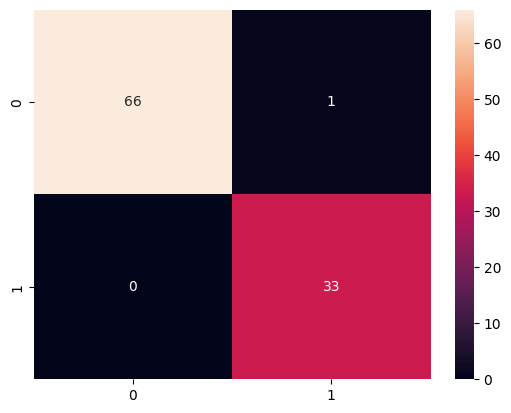

In [19]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc = roc_auc_score(
y_test,
y_proba[:, 1]
)
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.99
ROC-AUC Score: 1.0


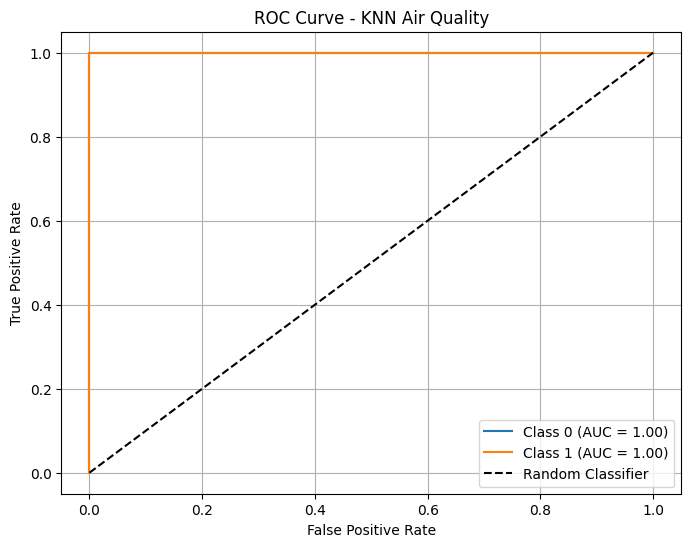

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities
y_proba = knn.predict_proba(x_test)

# Get unique classes from y_test
unique_classes = np.unique(y_test)
n_classes = len(unique_classes)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    # Dynamically create binary true labels for the current class
    true_labels_for_class = (y_test == unique_classes[i]).astype(int)
    predicted_proba_for_class = y_proba[:, i]

    fpr, tpr, _ = roc_curve(true_labels_for_class, predicted_proba_for_class)
    auc_score = roc_auc_score(true_labels_for_class, predicted_proba_for_class)
    plt.plot(
        fpr, tpr,
        label=f'Class {unique_classes[i]} (AUC = {auc_score:.2f})'
    )

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Air Quality')
plt.legend()
plt.grid()
plt.show()

In [28]:
overall_auc = roc_auc_score(
y_test,
y_proba[:, 1]
)
print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 1.0
